In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import math, copy


In [3]:
np.set_printoptions(precision=2)

In [4]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [5]:
def predict_cost_with_loop(x,w,b):

    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i] * w[i]  
        p = p + p_i         
    p = p + b                
    return p

In [6]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])


In [7]:
x_vec = X_train[0,:]
print(x_vec)
predict = predict_cost_with_loop(x=x_vec,w= w_init,b= b_init)
predict

[2104    5    1   45]


np.float64(459.9999976194083)

In [8]:
def dot_prediction(x,w,b):
    
    return np.dot(x,w) + b

In [9]:
dot_prediction(x_vec, w_init, b_init)

np.float64(459.99999761940825)

In [10]:
def compute_cost(x, y, w,b ):
    m = x.shape[0]
    final_cost = 0
    cost = 0
    for i in range(m):
        cost += (np.dot(x[i], w) + b - y[i]) **2
    
    final_cost = cost/(2 * m)

    return final_cost

In [11]:
print(compute_cost(X_train, y_train, w_init, b_init))

1.5578904880036537e-12


In [24]:
def compute_gradient(x,y,w,b):
    m,n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err  = (np.dot(x[i],w)+b - y[i])
        for j in range(n):
            dj_dw[j] += err * x[i,j]
        dj_db += err
    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

    



In [ ]:
def gradient_descent(x,y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    j_hist = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:
            j_hist.append(cost_function(x,y,w,b))
        if i % math.ceil(num_iters/10) == 0:
            print(f"Iteration {i}: Cost{j_hist[-1]:8.2f}")
    return w,b, j_hist

In [ ]:
w_init = np.zeros_like(w_init)
b_init  = 0.
iterations =10000
alpha = 5.0e-7
w_fin, b_fin, j_hist = gradient_descent(X_train, y_train, w_init, b_init, cost_fuction=compute_cost, gradient_function=compute_gradient, alpha=alpha, num_iters=iterations)

print(f"W = {w_fin} \n B = {b_fin}")

Iteration 0: Cost 2529.46
Iteration 1000: Cost  686.69
Iteration 2000: Cost  677.19
Iteration 3000: Cost  668.48
Iteration 4000: Cost  660.50
Iteration 5000: Cost  653.19
Iteration 6000: Cost  646.49
Iteration 7000: Cost  640.35
Iteration 8000: Cost  634.72
Iteration 9000: Cost  629.56
W = [ 0.22  0.03 -0.11 -0.58] 
 B = -0.019077710470483206


In [30]:
x_train

NameError: name 'x_train' is not defined

Text(0.5, 0, 'iteration')

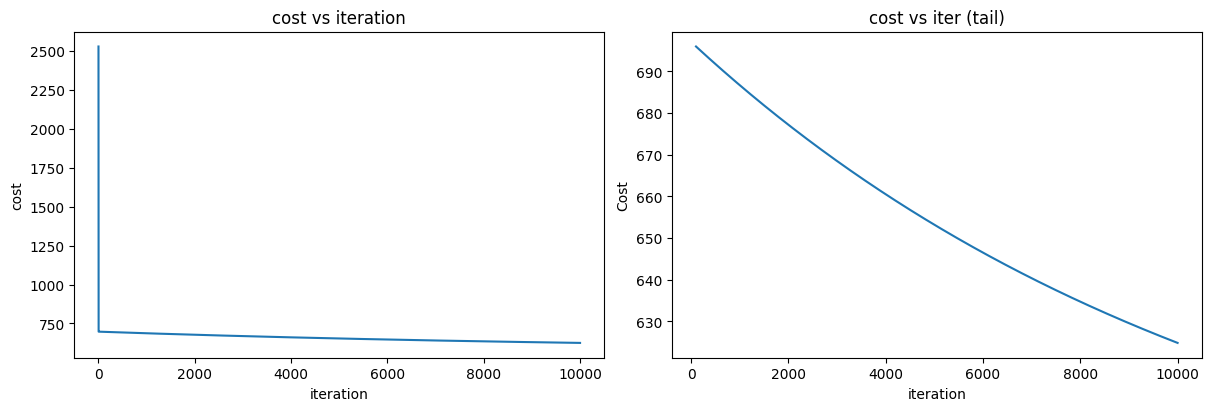

In [27]:
fig, (ax1, ax2) = plt.subplots(1,2, constrained_layout = True, figsize=(12,4))

ax1.plot(j_hist)
ax2.plot(100+np.arange(len(j_hist[100:])), j_hist[100:])
ax1.set_title("cost vs iteration"); ax2.set_title("cost vs iter (tail)")
ax1.set_ylabel("cost"); ax2.set_ylabel("Cost")
ax1.set_xlabel("iteration"); ax2.set_xlabel("iteration")